# Phantom Fairness: the fairness illusion created by label noise

### Part 1 of 3 - Data wiring, exploratory analysis, and frozen-embedding extraction

**Working thesis.** The apparent demographic fairness of NIH-trained chest radiograph models is, in part, an artefact of how the NIH ChestX-ray14 labels were produced (automated NLP mining of free-text reports), and this apparent fairness degrades once the same predictions are scored against radiologist-verified labels, including labels from a different continent (PadChest, Spain).

**Why this matters.** The dominant narrative in imaging fairness is that AI systems *underdiagnose* under-served groups (Seyyed-Kalantari et al., 2021, *Nature Medicine*; Larrazabal et al., 2020, *PNAS*). This study examines a complementary and, in places, opposing mechanism: that a *small measured gap* can itself be an artefact. If the reference labels carry subgroup-structured noise, then a fairness metric computed against those labels can look reassuring while the underlying clinical behaviour is biased. We refer to this as *phantom fairness*.

**Design at a glance.**
- Frozen image embeddings plus linear heads plus classical statistics. No end-to-end training is required, so the full pipeline runs on a CPU-only Intel i7 laptop.
- Three label regimes for the same images: NIH NLP labels (noisy), NIH-Google radiologist-adjudicated labels (clean, four findings; Majkowska et al., 2020, *Radiology*), and PadChest manually labelled samples (clean, different continent; Bustos et al., 2020, *Medical Image Analysis*).
- A causal noise-injection experiment that re-creates the fairness illusion on clean PadChest labels, plus an inexpensive subgroup-threshold remedy.

**Contributions (positioned for an elite hybrid Q1 venue: IEEE JBHI, AIM, CMPB, JBI, TMI, MedIA).**
1. A reproducible, CPU-only audit that separates *label-induced* fairness from *model-induced* fairness across three label regimes and two continents.
2. A quantification of subgroup-structured label noise in NIH (NLP versus adjudicated), including the case of *Fracture*, a finding that has no NLP counterpart in NIH-14 at all and therefore behaves as a clean example of structured missing-label noise.
3. A causal demonstration that injecting NIH-estimated subgroup-specific noise into clean PadChest labels reproduces the fairness illusion, establishing label noise as a sufficient mechanism rather than a correlate.
4. An inexpensive, training-free remedy (subgroup-specific decision-threshold re-estimation) with quantified fairness improvement and an honest cost-benefit account.

**Reproducibility stance.** Every input file is hashed (SHA-256), every random seed is fixed, every library version is recorded, and all embeddings are cached deterministically. The provenance manifest written at the end of Part 1 is intended to satisfy a methods reviewer that the data wiring is exactly as described.


## Research question and pre-registration-style analysis plan

> **Primary research question.** To what extent is the measured demographic fairness of a chest radiograph classifier an artefact of label-generation noise rather than a property of the model, and does that apparent fairness survive evaluation against radiologist-verified labels from a second continent?

We separate *confirmatory* hypotheses (specified now, before modelling) from *exploratory* analyses (hypothesis-generating, reported as such). This separation is stated up front so that the eventual Results section can be read as a registered report rather than as a post-hoc narrative.

### Confirmatory hypotheses

| ID | Hypothesis | Primary test (Parts 2-3) | Direction |
|----|------------|--------------------------|-----------|
| H1 | A linear head on frozen embeddings, scored against **NIH NLP labels**, shows small subgroup gaps (TPR gap, AUROC gap) across sex, age band, and projection. | Bootstrap subgroup gaps with 95% CIs | Small / "fair" |
| H2 | NIH label noise (NLP versus adjudicated) is **subgroup-structured**, not uniform, with elevated false-negative noise in specific intersections (for example elderly women). | McNemar and stratified noise rates with CIs | Differential |
| H3 | The same predictions, scored against **adjudicated NIH** and **clean PadChest** labels, show **wider** subgroup gaps than against NLP labels. | Paired gap comparison across label regimes | Gaps widen |
| H4 | Injecting NIH-estimated subgroup-specific noise into **clean PadChest** labels **shrinks** measured gaps back toward "fair". | Noise-injection simulation with CIs | Gaps shrink |
| H5 | Subgroup-specific **threshold re-estimation** reduces TPR gaps on clean labels without retraining. | Pre/post gap comparison | Gaps shrink |

H1-H3 are the primary confirmatory chain (phantom fairness exists and evaporates). H4 is the mechanistic confirmation (label noise is *sufficient* to generate the illusion). H5 is the remedy.

### Exploratory analyses (reported as exploratory)
- Ablation across embedding backbones (domain-specific versus general vision versus vision-language).
- Sensitivity to the airspace-opacity mapping choice and to subgroup band definitions.
- Bias amplification: model-level subgroup bias relative to label-level subgroup bias.
- Threshold-sweeping fairness curves and stratified calibration curves.

### Statistical plan (summary, executed in Parts 2-3)
- AUROC comparisons: DeLong test; subgroup gaps via stratified bootstrap (10,000 resamples, BCa intervals where feasible).
- Proportion gaps (TPR, FPR): two-proportion tests and bootstrap CIs.
- Label-noise contingency: McNemar test for paired discordance.
- Multiplicity: Benjamini-Hochberg control of the false discovery rate within each hypothesis family.
- Power: a-priori minimum-detectable-effect analysis for the small PadChest sample is computed in Part 1 (below) so that underpowered subgroups are flagged before any inference.

### Related-work anchors (for Discussion)
Underdiagnosis and TPR gaps in CXR classifiers (Seyyed-Kalantari et al., 2020 CheXclusion; 2021 *Nat Med*); sex imbalance producing biased CAD (Larrazabal et al., 2020 *PNAS*); algorithmic encoding of protected attributes (Glocker et al., 2023 *eBioMedicine*); calibration-metric bias under small samples; and the data-quality literature on NIH-14 label noise (Oakden-Rayner, 2020; Majkowska et al., 2020). The contribution here is to connect the *label-quality* and *fairness* literatures causally.

### Ethics and limitations (previewed; expanded in Part 3)
This is a secondary analysis of de-identified public datasets used under their respective data-use agreements (NIH open release; PadChest research licence; PhysioNet-style terms where applicable). The PadChest sample is small, which constrains the precision of cross-continental claims; we therefore treat PadChest results as confirmatory for direction and exploratory for magnitude, and we quantify power explicitly.


## Scope of Part 1

Part 1 establishes and *verifies* the data wiring that everything else depends on. By the end of this notebook you will have:

1. A reproducible configuration and provenance manifest (hashed inputs, fixed seeds, recorded versions).
2. Indexed NIH images across `images_001 ... images_012`, joined to NIH NLP labels and to NIH-Google adjudicated labels.
3. Indexed and parsed PadChest sample images and labels.
4. A single canonical four-finding label space shared across all three regimes, with an explicit, editable mapping table.
5. Subgroup assignments (sex, age band, projection, and the intersectional elderly-women group) for every dataset.
6. Exploratory data analysis and publication-style figures that confirm the wiring is correct.
7. An a-priori power analysis for the PadChest subgroups.
8. A backbone-agnostic frozen-embedding extractor with deterministic caching, demonstrated on a small subset for each available backbone (the ablation switch).

Part 1 deliberately does **not** train heads, compute fairness metrics, or run the noise experiments. Those are Parts 2 and 3.


---
## 1. Environment, dependencies, and imports

The pipeline is intentionally light. The only heavyweight optional dependencies are the embedding backbones, each of which is imported defensively so that a missing package degrades to a clear message rather than a crash. Run the install cell once, then restart the kernel.

In [2]:
# One-time installation (uncomment to run, then restart the kernel).

!pip install numpy pandas scipy scikit-learn matplotlib pillow tqdm pyarrow statsmodels
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install torchxrayvision          # domain-specific CXR backbone (primary)
!pip install open_clip_torch          # CLIP / BiomedCLIP backbones (ablation)
!pip install openpyxl xlrd            # in case the PadChest sample is a real .xls/.xlsx
print("If packages are missing, uncomment the lines above, run, then restart the kernel.")

Looking in indexes: https://download.pytorch.org/whl/cpu
  Obtaining dependency information for torch from https://download-r2.pytorch.org/whl/cpu/torch-2.12.1%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for torchvision from https://download-r2.pytorch.org/whl/cpu/torchvision-0.27.1%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for typing-extensions>=4.10.0 from https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata
  Obtaining dependency information for sympy>=1.13.3 from https://files.pythonhosted.org/packages/a2/09/77d55d46fd61b4a135c444fc97158ef34a095e5681d0a6c10b75bf356191/sympy-1.14.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/122.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/122.9 MB 3.2 MB/s eta 0:00:39
   ---------------------------------------- 0.5/122.9 MB 5.7 MB/s eta 0:00:22
   ---------------------------------------- 1.4/122.9 MB 1

ERROR: Invalid requirement: '#'
ERROR: Invalid requirement: '#'


If packages are missing, uncomment the lines above, run, then restart the kernel.


ERROR: Invalid requirement: '#'


In [3]:
# Core imports (always required).
import os
import re
import gc
import json
import time
import hashlib
import logging
import warnings
import platform
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple, Callable

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Optional imports are attempted lazily inside the backbone registry (Section 9).
def _try_import(name):
    try:
        return __import__(name)
    except Exception as exc:  # noqa: BLE001
        logging.getLogger("phantom").info("Optional import unavailable: %s (%s)", name, exc)
        return None

print("Core imports ready. pandas", pd.__version__, "| numpy", np.__version__)

Core imports ready. pandas 3.0.3 | numpy 2.4.4


---
## 2. Configuration

Every path, label space, mapping, and switch lives in a single immutable-by-convention `Config` object so that a reviewer can see the entire experimental surface at a glance and a collaborator can reproduce it by editing one cell. Paths below match the folder layout supplied on the local Windows machine.

Two wiring facts are encoded here and are worth stating plainly:

- The four **canonical findings** are the radiologist-adjudicated findings of Majkowska et al. (2020): *Airspace opacity*, *Pneumothorax*, *Nodule or mass*, *Fracture*. These define the shared label space across NIH and PadChest.
- *Fracture* has **no** NLP counterpart in the NIH-14 vocabulary. We keep it in the canonical space precisely because its absence from the NLP labels is a clean, interpretable instance of structured label noise.

In [4]:
@dataclass
class Config:
    # ---- Local data roots (edit these to match your machine) ----
    nih_root: str = r"C:\Users\kruta\Downloads\NIH Chest X-rays"
    padchest_root: str = r"C:\Users\kruta\Downloads\PadChest Chest X-rays (sample)"

    # ---- Specific input files (expected locations) ----
    # NIH NLP labels (ships with the NIH download as Data_Entry_2017.csv).
    nih_labels_name: str = "Data_Entry_2017.csv"
    # NIH-Google adjudicated labels. Easiest source: the file packaged with
    # torchxrayvision, "google2019_nih-chest-xray-labels.csv.gz". The loader
    # also accepts the raw Google four-findings files
    # ("four_findings_expert_labels_validation_labels.csv" and
    #  "four_findings_expert_labels_test_labels.csv"). Place whichever you have
    # in the NIH root, or set an explicit path here.
    nih_google_name: str = "google2019_nih-chest-xray-labels.csv.gz"
    nih_google_raw_val: str = "four_findings_expert_labels_validation_labels.csv"
    nih_google_raw_test: str = "four_findings_expert_labels_test_labels.csv"
    # PadChest sample labels (Windows shows it as "XLS Worksheet"; could be csv or xls).
    padchest_labels_name: str = "chest_x_ray_images_labels_sample.csv"
    padchest_image_subdir: str = "sample"
    nih_image_subdirs_glob: str = "images_*"   # images_001 ... images_012

    # ---- Output workspace (created automatically next to the notebook) ----
    project_dir: str = str(Path.cwd() / "phantom_fairness")

    # ---- Canonical four-finding label space (Majkowska et al., 2020) ----
    canonical_findings: Tuple[str, ...] = (
        "Airspace opacity", "Pneumothorax", "Nodule or mass", "Fracture",
    )

    # ---- Subgroup band definitions (exploratory sensitivity uses alternatives) ----
    age_bands: Tuple[Tuple[str, float, float], ...] = (
        ("<40", 0.0, 40.0),
        ("40-60", 40.0, 60.0),
        (">60", 60.0, 200.0),
    )
    elderly_age_threshold: float = 60.0   # for the intersectional elderly-women group

    # ---- Embedding backbones for the ablation (Section 9) ----
    # The primary, most defensible backbone is the domain-specific CXR model.
    embedding_backbones: Tuple[str, ...] = (
        "xrv_densenet121",   # primary: TorchXRayVision DenseNet-121 (CXR-trained), 1024-d
        "resnet50_imagenet", # general vision, 2048-d
        "clip_vitb32",       # general vision-language, 512-d
        # "biomedclip",      # biomedical vision-language, 512-d (optional, heavier download)
    )
    embed_batch_size: int = 32
    embed_image_size: int = 224
    l2_normalise_embeddings: bool = False   # store raw; normalise in Part 2 if needed

    # ---- Reproducibility and compute ----
    random_seed: int = 1997
    cpu_threads: int = max(1, (os.cpu_count() or 4) - 1)

    # ---- Part-1 wiring switches (keep the demo fast) ----
    demo_subset_size: int = 64       # images per backbone for the extraction demo
    run_embedding_demo: bool = True
    strict_paths: bool = False       # if True, missing files raise; if False, warn and skip

    def __post_init__(self):
        self.nih_root = str(self.nih_root)
        self.padchest_root = str(self.padchest_root)

    # ---- Derived paths ----
    @property
    def nih_labels_path(self) -> Path: return Path(self.nih_root) / self.nih_labels_name
    @property
    def nih_google_path(self) -> Path: return Path(self.nih_root) / self.nih_google_name
    @property
    def padchest_labels_path(self) -> Path: return Path(self.padchest_root) / self.padchest_labels_name
    @property
    def padchest_image_dir(self) -> Path: return Path(self.padchest_root) / self.padchest_image_subdir
    @property
    def out(self) -> Path: return Path(self.project_dir)
    @property
    def cache_dir(self) -> Path: return self.out / "cache"
    @property
    def emb_dir(self) -> Path: return self.out / "embeddings"
    @property
    def fig_dir(self) -> Path: return self.out / "figures"
    @property
    def tab_dir(self) -> Path: return self.out / "tables"
    @property
    def prov_dir(self) -> Path: return self.out / "provenance"

CFG = Config()
for d in (CFG.out, CFG.cache_dir, CFG.emb_dir, CFG.fig_dir, CFG.tab_dir, CFG.prov_dir):
    d.mkdir(parents=True, exist_ok=True)

print("Project workspace:", CFG.out)
print("Canonical findings:", list(CFG.canonical_findings))
print("Backbones (ablation):", list(CFG.embedding_backbones))

Project workspace: C:\Users\kruta\Downloads\phantom_fairness
Canonical findings: ['Airspace opacity', 'Pneumothorax', 'Nodule or mass', 'Fracture']
Backbones (ablation): ['xrv_densenet121', 'resnet50_imagenet', 'clip_vitb32']


---
## 3. Reproducibility setup

Fixed seeds, bounded CPU threading (so the laptop stays responsive), a quiet but informative logger, and a consistent figure style. Library versions are captured for the provenance manifest.

In [5]:
def set_global_determinism(seed: int, threads: int) -> dict:
    os.environ["PYTHONHASHSEED"] = str(seed)
    import random as _random
    _random.seed(seed)
    np.random.seed(seed)
    versions = {"python": platform.python_version(), "numpy": np.__version__,
                "pandas": pd.__version__, "matplotlib": matplotlib.__version__,
                "platform": platform.platform()}
    torch = _try_import("torch")
    if torch is not None:
        torch.manual_seed(seed)
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except Exception:
            pass
        torch.set_num_threads(int(threads))
        versions["torch"] = torch.__version__
    return versions

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger("phantom")

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.autolayout": True,
})

VERSIONS = set_global_determinism(CFG.random_seed, CFG.cpu_threads)
log.info("Determinism set. seed=%s threads=%s", CFG.random_seed, CFG.cpu_threads)
print(json.dumps(VERSIONS, indent=2))

14:46:24 [INFO] Determinism set. seed=1997 threads=13


{
  "python": "3.11.15",
  "numpy": "2.4.4",
  "pandas": "3.0.3",
  "matplotlib": "3.11.0",
  "platform": "Windows-10-10.0.26200-SP0",
  "torch": "2.12.1+cpu"
}


---
## 4. Data provenance and integrity

To make the wiring auditable, we record a SHA-256 digest of each label file, the row and image counts, and the library versions. The manifest is finalised at the end of Part 1 once everything has loaded, and is written to `provenance/`. This mirrors a hash-anchored provenance practice and is what lets a reviewer confirm that the numbers in the paper came from exactly these inputs.

In [6]:
def sha256_of_file(path: Path, chunk: int = 1 << 20) -> Optional[str]:
    path = Path(path)
    if not path.exists():
        return None
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def sha256_of_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

PROVENANCE: dict = {
    "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "seed": CFG.random_seed,
    "versions": VERSIONS,
    "config": {k: (str(v) if isinstance(v, Path) else v) for k, v in asdict(CFG).items()},
    "inputs": {},     # filled as files are loaded
    "counts": {},     # filled during EDA
}

def register_input(key: str, path: Path):
    p = Path(path)
    PROVENANCE["inputs"][key] = {
        "path": str(p), "exists": p.exists(),
        "sha256": sha256_of_file(p),
        "bytes": (p.stat().st_size if p.exists() else None),
    }
    return PROVENANCE["inputs"][key]

print("Provenance scaffold ready. Inputs will be hashed as they load.")

Provenance scaffold ready. Inputs will be hashed as they load.


---
## 5. NIH image indexing

The NIH download spreads 112,120 PNGs across `images_001 ... images_012`, each with an inner `images/` folder. We build a filename to absolute-path index once and cache it to Parquet, so later cells never re-walk the disk. The index is keyed by the bare filename (for example `00030753_009.png`), which is exactly how the NIH label CSV references each image.

In [7]:
def index_nih_images(cfg: Config, use_cache: bool = True) -> pd.DataFrame:
    cache = cfg.cache_dir / "nih_image_index.parquet"
    if use_cache and cache.exists():
        df = pd.read_parquet(cache)
        log.info("Loaded cached NIH image index: %d images", len(df))
        return df

    root = Path(cfg.nih_root)
    rows = []
    subdirs = sorted(root.glob(cfg.nih_image_subdirs_glob))
    if not subdirs:
        log.warning("No NIH image subfolders matched %s under %s", cfg.nih_image_subdirs_glob, root)
    for sub in subdirs:
        img_folder = sub / "images"
        if not img_folder.exists():
            # Some mirrors omit the inner folder; fall back to the subdir itself.
            img_folder = sub
        for p in img_folder.glob("*.png"):
            rows.append({"Image Index": p.name, "image_path": str(p), "shard": sub.name})
    df = pd.DataFrame(rows)
    if len(df):
        df = df.drop_duplicates("Image Index").reset_index(drop=True)
        df.to_parquet(cache, index=False)
    log.info("Indexed %d NIH images across %d shards", len(df), len(subdirs))
    return df

nih_index = index_nih_images(CFG)
register_input("nih_labels", CFG.nih_labels_path)
display(nih_index.head(3))
print("Total NIH images indexed:", len(nih_index))
if len(nih_index):
    print("Shards present:", sorted(nih_index["shard"].unique().tolist()))

14:46:25 [INFO] Loaded cached NIH image index: 112120 images


,Image Index,image_path,shard
0,00000001_000.png,C:\Users\kruta\Downloads\NIH Chest X-rays\imag...,images_001
1,00000001_001.png,C:\Users\kruta\Downloads\NIH Chest X-rays\imag...,images_001
2,00000001_002.png,C:\Users\kruta\Downloads\NIH Chest X-rays\imag...,images_001


Total NIH images indexed: 112120
Shards present: ['images_001', 'images_002', 'images_003', 'images_004', 'images_005', 'images_006', 'images_007', 'images_008', 'images_009', 'images_010', 'images_011', 'images_012']


---
## 6. NIH NLP labels (the noisy regime)

`Data_Entry_2017.csv` carries the NLP-mined labels for fourteen findings plus *No Finding*, together with patient sex, age, and view position. We parse the pipe-delimited `Finding Labels` field into a clean one-hot matrix, sanitise the age field (older NIH releases encoded anomalies such as ages above 120, which we set to missing), and standardise sex and view.

The fourteen NIH findings are: Atelectasis, Cardiomegaly, Effusion, Infiltration, Mass, Nodule, Pneumonia, Pneumothorax, Consolidation, Edema, Emphysema, Fibrosis, Pleural_Thickening, Hernia. Note again that *Fracture* is absent.

In [8]:
NIH14 = ["Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass",
         "Nodule", "Pneumonia", "Pneumothorax", "Consolidation", "Edema",
         "Emphysema", "Fibrosis", "Pleural_Thickening", "Hernia"]

def _parse_age(val) -> float:
    # Handles integers, "058", "058Y", "12M", "30D". Returns years, NaN if implausible.
    if pd.isna(val):
        return np.nan
    s = str(val).strip().upper()
    m = re.match(r"^(\d+(?:\.\d+)?)\s*([YMD]?)$", s)
    if not m:
        digits = re.sub(r"[^0-9.]", "", s)
        if digits == "":
            return np.nan
        years = float(digits)
    else:
        years = float(m.group(1))
        unit = m.group(2) or "Y"
        if unit == "M":
            years = years / 12.0
        elif unit == "D":
            years = years / 365.25
    if years <= 0 or years > 120:
        return np.nan
    return years

def load_nih_labels(cfg: Config) -> pd.DataFrame:
    path = cfg.nih_labels_path
    if not path.exists():
        msg = f"NIH labels not found at {path}"
        if cfg.strict_paths: raise FileNotFoundError(msg)
        log.warning(msg); return pd.DataFrame()
    df = pd.read_csv(path)
    # Standardise the columns we rely on (names are stable in Data_Entry_2017.csv).
    ren = {"Patient Age": "age_raw", "Patient Gender": "sex",
           "View Position": "view", "Patient ID": "patient_id"}
    df = df.rename(columns={k: v for k, v in ren.items() if k in df.columns})
    # One-hot the pipe-delimited finding string.
    fl = df["Finding Labels"].fillna("").str.split("|")
    for f in NIH14:
        df["nih_" + f] = fl.apply(lambda lst, f=f: int(f in lst))
    df["nih_No_Finding"] = fl.apply(lambda lst: int("No Finding" in lst))
    # Demographics.
    df["age"] = df["age_raw"].apply(_parse_age)
    df["sex"] = df["sex"].astype(str).str.upper().str[0].map({"M": "M", "F": "F"})
    df["view"] = df["view"].astype(str).str.upper().str.strip()
    keep = ["Image Index", "patient_id", "age", "sex", "view"] + \
           ["nih_" + f for f in NIH14] + ["nih_No_Finding"]
    out = df[[c for c in keep if c in df.columns]].copy()
    log.info("Loaded NIH NLP labels: %d rows", len(out))
    return out

nih_labels = load_nih_labels(CFG)
if len(nih_labels):
    display(nih_labels.head(3))
    prev = {f: int(nih_labels["nih_" + f].sum()) for f in NIH14}
    print("NIH NLP positive counts (top 6):",
          dict(sorted(prev.items(), key=lambda kv: -kv[1])[:6]))

14:46:29 [INFO] Loaded NIH NLP labels: 112120 rows


,Image Index,patient_id,age,sex,view,nih_Atelectasis,nih_Cardiomegaly,nih_Effusion,nih_Infiltration,nih_Mass,nih_Nodule,nih_Pneumonia,nih_Pneumothorax,nih_Consolidation,nih_Edema,nih_Emphysema,nih_Fibrosis,nih_Pleural_Thickening,nih_Hernia,nih_No_Finding
0,00000001_000.png,1,58.0,M,PA,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,1,58.0,M,PA,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,00000001_002.png,1,58.0,M,PA,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0


NIH NLP positive counts (top 6): {'Infiltration': 19894, 'Effusion': 13317, 'Atelectasis': 11559, 'Nodule': 6331, 'Mass': 5782, 'Pneumothorax': 5302}


---
## 7. NIH-Google radiologist-adjudicated labels (the clean NIH regime)

Majkowska et al. (2020, *Radiology*) released adjudicated labels for four findings over 4,374 NIH studies (validation and test splits, adjudicated by panels of radiologists). These are the *clean* NIH reference.

The loader is deliberately format-tolerant because there are two common sources:
1. the file packaged with **torchxrayvision** (`google2019_nih-chest-xray-labels.csv.gz`), which already carries NIH metadata plus the four label columns; and
2. the **raw Google** files (`four_findings_expert_labels_{validation,test}_labels.csv`).

We normalise every label encoding (`YES`/`NO`, `1`/`0`, booleans) to `{0, 1}`, standardise the image-key column to `Image Index`, and expose the four findings under the canonical names. Where a `mass`/`nodule` distinction appears separately, it is unioned into *Nodule or mass*.

In [9]:
def ensure_adjudicated_csv(cfg):
    # Auto-discover the adjudicated CSV bundled with torchxrayvision if it is not beside the images.
    dest = cfg.nih_google_path
    if dest.exists():
        return dest
    try:
        import torchxrayvision as xrv
        pkg = Path(os.path.dirname(xrv.datasets.__file__)) / "data"
        cands = list(pkg.glob("google2019_nih-chest-xray-labels.csv*")) or \
                list(Path(os.path.dirname(xrv.__file__)).rglob("*google2019*nih*chest*xray*labels*.csv*"))
        if cands:
            try:
                import shutil; shutil.copyfile(cands[0], dest); return dest
            except Exception:
                return cands[0]
    except Exception as exc:
        log.warning("Could not auto-discover adjudicated CSV: %s", exc)
    return dest

In [10]:
# Map various source column spellings onto our canonical findings.
GOOGLE_COL_SYNONYMS = {
    "Airspace opacity": ["Airspace opacity", "Airspace_Opacity", "Lung Opacity",
                          "Lung_Opacity", "airspace_opacity", "opacity"],
    "Pneumothorax":     ["Pneumothorax", "pneumothorax"],
    "Nodule or mass":   ["Nodule or mass", "Nodule/mass", "Nodule_or_mass",
                          "nodule_mass", "nodule/mass"],
    "Fracture":         ["Fracture", "fracture"],
}
_YES = {"YES", "Y", "1", "1.0", "TRUE", "T", "POSITIVE"}
_NO = {"NO", "N", "0", "0.0", "FALSE", "F", "NEGATIVE", ""}

def _to01(series: pd.Series) -> pd.Series:
    def conv(v):
        if pd.isna(v): return np.nan
        s = str(v).strip().upper()
        if s in _YES: return 1
        if s in _NO: return 0
        try: return 1 if float(s) >= 0.5 else 0
        except Exception: return np.nan
    return series.map(conv)

def _standardise_image_key(df: pd.DataFrame) -> pd.DataFrame:
    for c in ["Image Index", "image_id", "ImageID", "Image", "filename", "image"]:
        if c in df.columns:
            df = df.rename(columns={c: "Image Index"})
            break
    df["Image Index"] = df["Image Index"].astype(str).str.strip()
    # Ensure a .png suffix to match the NIH index keys.
    df["Image Index"] = df["Image Index"].apply(
        lambda s: s if s.lower().endswith(".png") else (s + ".png"))
    return df

def _extract_canonical_from_google(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame()
    out["Image Index"] = df["Image Index"]
    for canon, syns in GOOGLE_COL_SYNONYMS.items():
        col = next((s for s in syns if s in df.columns), None)
        if col is not None:
            out["adj_" + canon] = _to01(df[col])
        else:
            out["adj_" + canon] = np.nan   # finding not present in this source
    if "View Position" in df.columns:
        out["adj_view"] = df["View Position"].astype(str).str.upper().str.strip()
    return out

def load_nih_google_labels(cfg: Config) -> pd.DataFrame:
    packaged = cfg.nih_google_path
    raw_val = Path(cfg.nih_root) / cfg.nih_google_raw_val
    raw_test = Path(cfg.nih_root) / cfg.nih_google_raw_test
    frames = []
    if packaged.exists():
        df = pd.read_csv(packaged)
        df = _standardise_image_key(df)
        frames.append(_extract_canonical_from_google(df))
        register_input("nih_google_packaged", packaged)
        log.info("Loaded packaged Google adjudicated labels: %d rows", len(df))
    if raw_val.exists() or raw_test.exists():
        for p, split in [(raw_val, "validation"), (raw_test, "test")]:
            if p.exists():
                d = pd.read_csv(p)
                d = _standardise_image_key(d)
                cdf = _extract_canonical_from_google(d)
                cdf["adj_split"] = split
                frames.append(cdf)
                register_input(f"nih_google_{split}", p)
                log.info("Loaded raw Google %s labels: %d rows", split, len(d))
    if not frames:
        msg = (f"No Google adjudicated file found. Place '{cfg.nih_google_name}' "
               f"(from torchxrayvision) or the raw four_findings_*.csv in {cfg.nih_root}.")
        if cfg.strict_paths: raise FileNotFoundError(msg)
        log.warning(msg); return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    # If both sources overlap, keep the first non-null per image per finding.
    agg = {c: "first" for c in out.columns if c != "Image Index"}
    out = out.groupby("Image Index", as_index=False).agg(agg)
    log.info("Adjudicated labels (deduplicated): %d unique images", len(out))
    return out

nih_google = load_nih_google_labels(CFG)
if len(nih_google):
    display(nih_google.head(3))
    for canon in CFG.canonical_findings:
        col = "adj_" + canon
        if col in nih_google.columns:
            pos = int(np.nansum(nih_google[col].values))
            n = int(nih_google[col].notna().sum())
            print(f"  adjudicated {canon:16s}: {pos:5d} positive / {n} labelled")

14:46:29 [INFO] Loaded packaged Google adjudicated labels: 4376 rows
14:46:29 [INFO] Adjudicated labels (deduplicated): 4376 unique images


,Image Index,adj_Airspace opacity,adj_Pneumothorax,adj_Nodule or mass,adj_Fracture,adj_view
0,00000013_008.png,1,0,0,0,AP
1,00000013_026.png,0,1,0,0,AP
2,00000032_002.png,1,0,0,0,AP


  adjudicated Airspace opacity:  2166 positive / 4376 labelled
  adjudicated Pneumothorax    :   238 positive / 4376 labelled
  adjudicated Nodule or mass  :   605 positive / 4376 labelled
  adjudicated Fracture        :   186 positive / 4376 labelled


---
## 8. PadChest sample (the clean, second-continent regime)

PadChest (San Juan Hospital, Alicante, Spain) supplies manually labelled radiographs whose `Labels` field is a stringified list of findings drawn from a hierarchical taxonomy. The sample folder holds the images; the sample spreadsheet holds the labels. We:

- read the labels file whether it is CSV or Excel;
- index the `sample/*.png` images;
- parse the `Labels` list and project it onto the four canonical findings using an explicit, editable term mapping;
- derive age (study year minus birth year), sex (`PatientSex_DICOM`), and projection.

The airspace-opacity mapping is a reported design choice, not a hidden default; it is collected in one dictionary below so the sensitivity analysis in Part 3 can vary it cleanly.

In [11]:
# Explicit PadChest term -> canonical mapping (lowercase match; editable, reported).
PADCHEST_TERM_MAP = {
    "Airspace opacity": [
        "infiltrates", "alveolar pattern", "consolidation", "pneumonia",
        "air bronchogram", "increased density", "atypical pneumonia",
        "interstitial pattern", "ground glass pattern",
    ],
    "Pneumothorax": ["pneumothorax", "hydropneumothorax"],
    "Nodule or mass": ["nodule", "multiple nodules", "mass", "pulmonary mass",
                        "lung mass", "pseudonodule"],
    "Fracture": ["fracture", "rib fracture", "clavicle fracture",
                  "humeral fracture", "vertebral fracture", "callus rib fracture"],
}

def _read_table_any(path: Path) -> pd.DataFrame:
    # Windows may label a CSV as "XLS Worksheet". Try CSV, then Excel.
    try:
        return pd.read_csv(path)
    except Exception:
        pass
    for engine in ("openpyxl", "xlrd", None):
        try:
            return pd.read_excel(path, engine=engine) if engine else pd.read_excel(path)
        except Exception:
            continue
    raise IOError(f"Could not read {path} as CSV or Excel.")

def _parse_padchest_labels(cell) -> list:
    if pd.isna(cell): return []
    s = str(cell).strip()
    s = s.strip("[]")
    parts = re.split(r"[,;]", s)
    out = []
    for p in parts:
        t = p.strip().strip("'").strip('"').lower()
        if t and t not in ("nan", "normal"):
            out.append(t)
    return out

def index_padchest_images(cfg: Config) -> pd.DataFrame:
    d = cfg.padchest_image_dir
    rows = [{"ImageID": p.name, "image_path": str(p)} for p in d.glob("*.png")] if d.exists() else []
    if not d.exists():
        log.warning("PadChest image dir not found: %s", d)
    df = pd.DataFrame(rows)
    log.info("Indexed %d PadChest sample images", len(df))
    return df

def load_padchest_labels(cfg: Config) -> pd.DataFrame:
    path = cfg.padchest_labels_path
    if not path.exists():
        # tolerate alternative extensions next to the configured name
        alt = list(Path(cfg.padchest_root).glob("chest_x_ray_images_labels_sample.*"))
        if alt: path = alt[0]
    if not path.exists():
        msg = f"PadChest labels not found at {cfg.padchest_labels_path}"
        if cfg.strict_paths: raise FileNotFoundError(msg)
        log.warning(msg); return pd.DataFrame()
    register_input("padchest_labels", path)
    df = _read_table_any(path)
    # Standardise the key column.
    if "ImageID" not in df.columns:
        for c in ["Image Index", "image_id", "filename", "Image"]:
            if c in df.columns:
                df = df.rename(columns={c: "ImageID"}); break
    df["ImageID"] = df["ImageID"].astype(str).str.strip()
    # Demographics.
    if "PatientSex_DICOM" in df.columns:
        df["sex"] = df["PatientSex_DICOM"].astype(str).str.upper().str[0].map({"M": "M", "F": "F"})
    else:
        df["sex"] = np.nan
    birth = pd.to_numeric(df.get("PatientBirth"), errors="coerce")
    study_year = (df.get("StudyDate_DICOM").astype(str).str[:4]
                  if "StudyDate_DICOM" in df.columns else pd.Series(np.nan, index=df.index))
    study_year = pd.to_numeric(study_year, errors="coerce")
    df["age"] = (study_year - birth).where(lambda s: (s > 0) & (s <= 120))
    # Projection -> PA / AP / Other.
    proj = (df.get("Projection") if "Projection" in df.columns else df.get("ViewPosition_DICOM"))
    proj = proj.astype(str).str.upper().str.strip() if proj is not None else pd.Series("", index=df.index)
    df["view"] = proj.where(proj.isin(["PA", "AP"]), other="OTHER")
    # Parse the label list and project to canonical findings.
    parsed = df.get("Labels", pd.Series([""] * len(df))).apply(_parse_padchest_labels)
    df["padchest_terms"] = parsed
    for canon, terms in PADCHEST_TERM_MAP.items():
        tset = set(t.lower() for t in terms)
        df["pc_" + canon] = parsed.apply(
            lambda lst, tset=tset: int(any(any(tt in item for tt in tset) for item in lst)))
    keep = ["ImageID", "sex", "age", "view", "padchest_terms"] + \
           ["pc_" + c for c in cfg.canonical_findings]
    out = df[[c for c in keep if c in df.columns]].copy()
    log.info("Loaded PadChest labels: %d rows", len(out))
    return out

padchest_index = index_padchest_images(CFG)
padchest_labels = load_padchest_labels(CFG)
if len(padchest_labels):
    display(padchest_labels.head(3))
    for canon in CFG.canonical_findings:
        c = "pc_" + canon
        if c in padchest_labels.columns:
            print(f"  PadChest {canon:16s}: {int(padchest_labels[c].sum())} positive / {len(padchest_labels)}")

14:46:29 [INFO] Indexed 24 PadChest sample images
14:46:29 [INFO] Loaded PadChest labels: 24 rows


,ImageID,sex,age,view,padchest_terms,pc_Airspace opacity,pc_Pneumothorax,pc_Nodule or mass,pc_Fracture
0,216840111366964012819207061112010316094555679_...,M,33.0,PA,[],0,0,0,0
1,216840111366964012373310883942009181081546904_...,M,61.0,PA,"[aortic elongation, copd signs]",0,0,0,0
2,126397712012687540784611673197697059691_fp0cu9...,F,10.0,OTHER,[unchanged],0,0,0,0


  PadChest Airspace opacity: 5 positive / 24
  PadChest Pneumothorax    : 0 positive / 24
  PadChest Nodule or mass  : 1 positive / 24
  PadChest Fracture        : 2 positive / 24


---
## 9. Canonical label space and the cross-dataset mapping table

All three regimes are projected onto the same four canonical findings so that fairness can be compared like for like. The NIH NLP labels are projected as follows:

- *Pneumothorax* maps directly from NIH `Pneumothorax`.
- *Nodule or mass* is the union of NIH `Nodule` and `Mass`.
- *Airspace opacity* is a reported design choice: the union of NIH `Infiltration` and `Consolidation` (a tighter mapping), with the option to widen it to include `Pneumonia`, `Edema`, and `Atelectasis` for the sensitivity analysis.
- *Fracture* has **no** NLP source, so its NLP projection is defined as all-negative. This is the point of the study, not a bug: the NLP regime is structurally blind to fractures, which is the cleanest possible form of subgroup-correlated label noise.

The mapping is materialised as a table and saved so it can be dropped straight into the paper's supplement.

In [12]:
# NIH-14 -> canonical projection (tight mapping is primary; wide is for sensitivity).
NIH_TO_CANON_TIGHT = {
    "Airspace opacity": ["Infiltration", "Consolidation"],
    "Pneumothorax": ["Pneumothorax"],
    "Nodule or mass": ["Nodule", "Mass"],
    "Fracture": [],   # no NLP counterpart in NIH-14 (intentional)
}
NIH_TO_CANON_WIDE = {
    "Airspace opacity": ["Infiltration", "Consolidation", "Pneumonia", "Edema", "Atelectasis"],
    "Pneumothorax": ["Pneumothorax"],
    "Nodule or mass": ["Nodule", "Mass"],
    "Fracture": [],
}

def project_nih_to_canonical(nih_lab: pd.DataFrame, mapping=NIH_TO_CANON_TIGHT,
                             prefix="nlp_") -> pd.DataFrame:
    out = nih_lab[["Image Index"]].copy()
    for canon, sources in mapping.items():
        if sources:
            cols = ["nih_" + s for s in sources if ("nih_" + s) in nih_lab.columns]
            out[prefix + canon] = (nih_lab[cols].sum(axis=1) > 0).astype(int) if cols else 0
        else:
            out[prefix + canon] = 0   # Fracture: structurally absent from NLP labels
    return out

nih_canon_nlp = project_nih_to_canonical(nih_labels, NIH_TO_CANON_TIGHT) if len(nih_labels) else pd.DataFrame()

# Build a human-readable mapping table for the supplement.
mapping_rows = []
for canon in CFG.canonical_findings:
    mapping_rows.append({
        "Canonical finding": canon,
        "NIH NLP source(s)": ", ".join(NIH_TO_CANON_TIGHT[canon]) or "(none - structurally absent)",
        "NIH adjudicated source": canon,
        "PadChest term(s)": ", ".join(PADCHEST_TERM_MAP.get(canon, []))[:80] + (
            "..." if len(", ".join(PADCHEST_TERM_MAP.get(canon, []))) > 80 else ""),
    })
mapping_table = pd.DataFrame(mapping_rows)
mapping_table.to_csv(CFG.tab_dir / "table_label_mapping.csv", index=False)
display(mapping_table)

,Canonical finding,NIH NLP source(s),NIH adjudicated source,PadChest term(s)
0,Airspace opacity,"Infiltration, Consolidation",Airspace opacity,"infiltrates, alveolar pattern, consolidation, ..."
1,Pneumothorax,Pneumothorax,Pneumothorax,"pneumothorax, hydropneumothorax"
2,Nodule or mass,"Nodule, Mass",Nodule or mass,"nodule, multiple nodules, mass, pulmonary mass..."
3,Fracture,(none - structurally absent),Fracture,"fracture, rib fracture, clavicle fracture, hum..."


---
## 10. Subgroup definitions

Subgroups are defined identically across datasets so that gaps are comparable. We define sex (`M`/`F`), three age bands (`<40`, `40-60`, `>60`), projection (`PA`/`AP`/`OTHER`), and the intersectional **elderly women** group (`F` and age above 60) that the underdiagnosis literature flags as high-risk. The assignment function is shared, which removes a common source of silent inconsistency between cohorts.

In [13]:
def assign_subgroups(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    out = df.copy()
    def band(a):
        if pd.isna(a): return "unknown"
        for name, lo, hi in cfg.age_bands:
            if lo <= a < hi: return name
        return "unknown"
    out["age_band"] = out["age"].apply(band)
    out["sex"] = out["sex"].fillna("unknown")
    out["view"] = out.get("view", pd.Series("unknown", index=out.index)).fillna("unknown")
    out["elderly_women"] = ((out["sex"] == "F") &
                            (out["age"] > cfg.elderly_age_threshold)).map({True: "F>60", False: "other"})
    return out

def subgroup_counts(df: pd.DataFrame, name: str) -> pd.DataFrame:
    recs = []
    for col in ["sex", "age_band", "view", "elderly_women"]:
        if col in df.columns:
            vc = df[col].value_counts(dropna=False)
            for k, v in vc.items():
                recs.append({"dataset": name, "axis": col, "group": str(k), "n": int(v)})
    return pd.DataFrame(recs)

print("Subgroup assignment ready (sex, age_band, view, elderly_women).")

Subgroup assignment ready (sex, age_band, view, elderly_women).


---
## 11. Data alignment: master frames

We now assemble one master frame per dataset. For NIH this joins, on `Image Index`: the image path, the NLP canonical labels, the adjudicated canonical labels (left join, with an `has_adjudicated` flag), and the subgroups. For PadChest it joins the sample images to the parsed labels and subgroups. Assertions guard the joins so that a silent key mismatch (a frequent cause of irreproducible fairness numbers) fails loudly.

In [14]:
def build_nih_master(cfg: Config) -> pd.DataFrame:
    if not len(nih_index) or not len(nih_labels):
        log.warning("NIH master skipped (missing index or labels)."); return pd.DataFrame()
    m = nih_index.merge(nih_labels, on="Image Index", how="inner")
    if len(nih_canon_nlp):
        m = m.merge(nih_canon_nlp, on="Image Index", how="left")
    if len(nih_google):
        m = m.merge(nih_google, on="Image Index", how="left")
        adj_cols = [c for c in m.columns if c.startswith("adj_") and c != "adj_view"]
        m["has_adjudicated"] = m[adj_cols].notna().any(axis=1) if adj_cols else False
    else:
        m["has_adjudicated"] = False
    m = assign_subgroups(m, cfg)
    assert m["Image Index"].is_unique, "NIH master has duplicate Image Index keys"
    log.info("NIH master: %d rows | %d with adjudicated labels",
             len(m), int(m["has_adjudicated"].sum()))
    return m

def build_padchest_master(cfg: Config) -> pd.DataFrame:
    if not len(padchest_index) or not len(padchest_labels):
        log.warning("PadChest master skipped (missing index or labels)."); return pd.DataFrame()
    m = padchest_index.merge(padchest_labels, on="ImageID", how="inner")
    m = assign_subgroups(m, cfg)
    matched = len(m); have_img = len(padchest_index); have_lab = len(padchest_labels)
    log.info("PadChest master: %d matched (images=%d, labels=%d)", matched, have_img, have_lab)
    if matched == 0:
        log.warning("Zero PadChest matches: check that ImageID equals the PNG filename.")
    return m

nih_master = build_nih_master(CFG)
padchest_master = build_padchest_master(CFG)
print("NIH master rows:", len(nih_master), "| PadChest master rows:", len(padchest_master))

14:46:30 [INFO] NIH master: 112120 rows | 4376 with adjudicated labels
14:46:30 [INFO] PadChest master: 24 matched (images=24, labels=24)


NIH master rows: 112120 | PadChest master rows: 24


---
## 12. Exploratory data analysis

The goal of the EDA is twofold: confirm the wiring (counts line up with the published dataset sizes) and surface the distributional facts that the fairness story depends on, in particular the sex-by-age structure and the canonical-finding prevalences across regimes.

In [15]:
# Prevalence of canonical findings across the three regimes.
def prevalence_table() -> pd.DataFrame:
    recs = []
    if len(nih_master):
        for canon in CFG.canonical_findings:
            c = "nlp_" + canon
            if c in nih_master.columns:
                recs.append({"regime": "NIH NLP", "finding": canon,
                             "prevalence": float(nih_master[c].mean()),
                             "n_pos": int(nih_master[c].sum()), "n": len(nih_master)})
        adj = nih_master[nih_master["has_adjudicated"]] if "has_adjudicated" in nih_master else nih_master.iloc[0:0]
        for canon in CFG.canonical_findings:
            c = "adj_" + canon
            if c in nih_master.columns and len(adj):
                sub = adj[adj[c].notna()]
                if len(sub):
                    recs.append({"regime": "NIH adjudicated", "finding": canon,
                                 "prevalence": float(sub[c].mean()),
                                 "n_pos": int(sub[c].sum()), "n": len(sub)})
    if len(padchest_master):
        for canon in CFG.canonical_findings:
            c = "pc_" + canon
            if c in padchest_master.columns:
                recs.append({"regime": "PadChest", "finding": canon,
                             "prevalence": float(padchest_master[c].mean()),
                             "n_pos": int(padchest_master[c].sum()), "n": len(padchest_master)})
    return pd.DataFrame(recs)

prev_tbl = prevalence_table()
if len(prev_tbl):
    prev_tbl.to_csv(CFG.tab_dir / "table_prevalence_by_regime.csv", index=False)
    display(prev_tbl.pivot_table(index="finding", columns="regime", values="prevalence").round(4))

# Subgroup counts across datasets.
sg = pd.concat([
    subgroup_counts(nih_master, "NIH") if len(nih_master) else pd.DataFrame(),
    subgroup_counts(padchest_master, "PadChest") if len(padchest_master) else pd.DataFrame(),
], ignore_index=True)
if len(sg):
    sg.to_csv(CFG.tab_dir / "table_subgroup_counts.csv", index=False)
    display(sg.head(20))

regime,NIH NLP,NIH adjudicated,PadChest
finding,,,
Airspace opacity,0.2082,0.4950,0.2083
Fracture,0.0000,0.0425,0.0833
Nodule or mass,0.1000,0.1383,0.0417
Pneumothorax,0.0473,0.0544,0.0000


,dataset,axis,group,n
0,NIH,sex,M,63340
1,NIH,sex,F,48780
2,NIH,age_band,40-60,49137
3,NIH,age_band,<40,35935
4,NIH,age_band,>60,27032
5,NIH,age_band,unknown,16
6,NIH,view,PA,67310
7,NIH,view,AP,44810
8,NIH,elderly_women,other,102322
9,NIH,elderly_women,F>60,9798


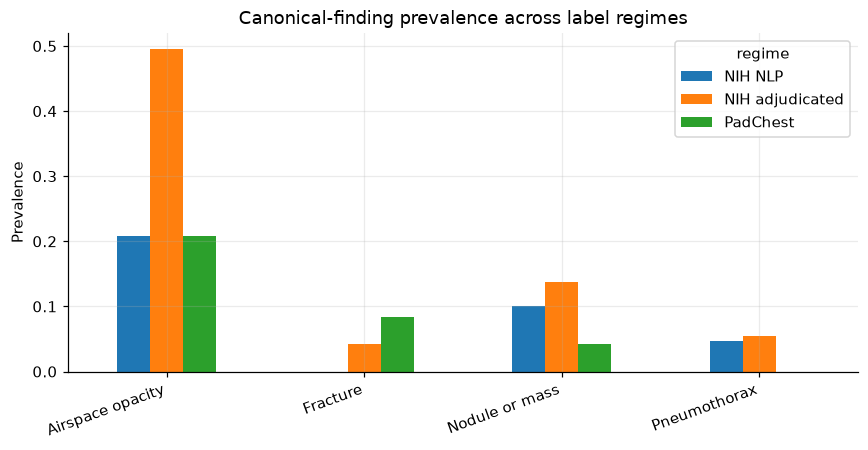

Note: Fracture should read ~0 under NIH NLP by construction (structural label noise).


In [16]:
# Figure 1: canonical-finding prevalence by regime (the headline wiring check).
if len(prev_tbl):
    piv = prev_tbl.pivot_table(index="finding", columns="regime", values="prevalence")
    ax = piv.plot(kind="bar", figsize=(8, 4.2))
    ax.set_ylabel("Prevalence"); ax.set_xlabel("")
    ax.set_title("Canonical-finding prevalence across label regimes")
    plt.xticks(rotation=20, ha="right")
    plt.savefig(CFG.fig_dir / "fig1_prevalence_by_regime.png", bbox_inches="tight")
    plt.show()
    print("Note: Fracture should read ~0 under NIH NLP by construction (structural label noise).")

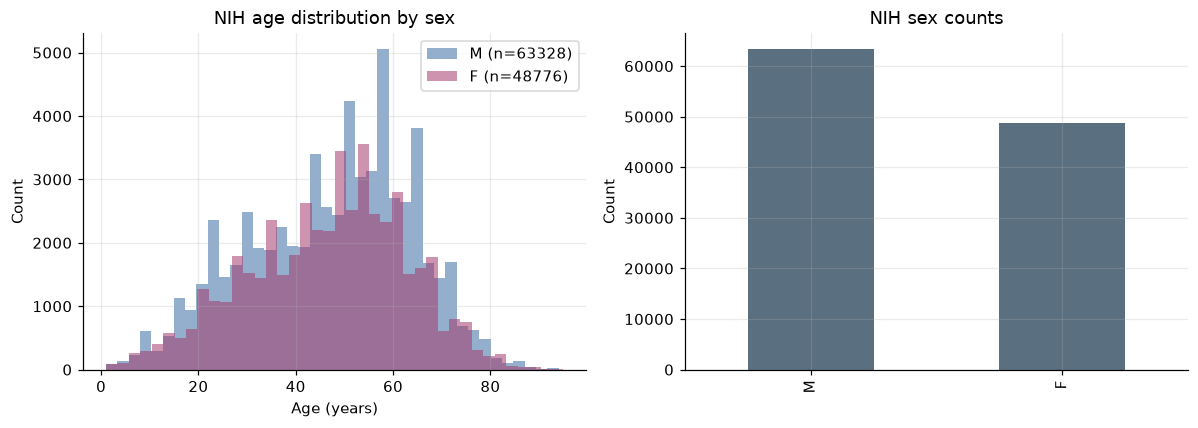

In [17]:
# Figure 2: NIH sex-by-age structure (the demographic axis of the fairness story).
if len(nih_master):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for s, axc in zip(["M", "F"], ["#3b6ea5", "#a53b6e"]):
        sub = nih_master[nih_master["sex"] == s]["age"].dropna()
        axes[0].hist(sub, bins=40, alpha=0.55, label=f"{s} (n={len(sub)})", color=axc)
    axes[0].set_title("NIH age distribution by sex"); axes[0].set_xlabel("Age (years)")
    axes[0].set_ylabel("Count"); axes[0].legend()
    nih_master["sex"].value_counts().plot(kind="bar", ax=axes[1], color="#5a6f80")
    axes[1].set_title("NIH sex counts"); axes[1].set_xlabel(""); axes[1].set_ylabel("Count")
    plt.savefig(CFG.fig_dir / "fig2_nih_sex_age.png", bbox_inches="tight")
    plt.show()

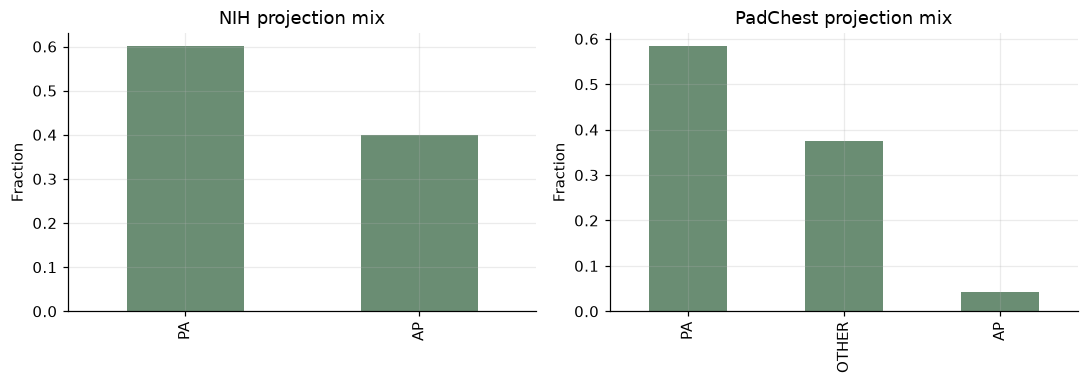

In [18]:
# Figure 3: projection mix per dataset (PA/AP can confound disease prevalence and fairness).
frames = []
if len(nih_master): frames.append(("NIH", nih_master["view"].value_counts(normalize=True)))
if len(padchest_master): frames.append(("PadChest", padchest_master["view"].value_counts(normalize=True)))
if frames:
    fig, axes = plt.subplots(1, len(frames), figsize=(5 * len(frames), 3.6), squeeze=False)
    for i, (name, vc) in enumerate(frames):
        vc.plot(kind="bar", ax=axes[0][i], color="#6a8d73")
        axes[0][i].set_title(f"{name} projection mix"); axes[0][i].set_ylabel("Fraction")
        axes[0][i].set_xlabel("")
    plt.savefig(CFG.fig_dir / "fig3_projection_mix.png", bbox_inches="tight")
    plt.show()

---
## 13. Label-noise wiring preview (NLP versus adjudicated)

This is a *wiring check*, not the analysis. The full subgroup-stratified noise quantification, McNemar tests, and heatmaps are in Part 2. Here we simply confirm that, on the images that carry adjudicated labels, the NLP labels and adjudicated labels are joined correctly and disagree in the expected direction. For *Fracture* the NLP regime is all-negative by construction, so every adjudicated positive is, definitionally, a false negative under NLP. That single fact is a compact preview of the whole thesis.

In [19]:
def noise_preview() -> pd.DataFrame:
    if not len(nih_master) or "has_adjudicated" not in nih_master.columns:
        print("No adjudicated overlap available for the preview."); return pd.DataFrame()
    adj = nih_master[nih_master["has_adjudicated"]].copy()
    if not len(adj):
        print("No rows with adjudicated labels matched the NIH image index."); return pd.DataFrame()
    recs = []
    for canon in CFG.canonical_findings:
        nlp_c, adj_c = "nlp_" + canon, "adj_" + canon
        if nlp_c in adj.columns and adj_c in adj.columns:
            sub = adj[adj[adj_c].notna()]
            if not len(sub): continue
            y_nlp = sub[nlp_c].astype(int).values
            y_adj = sub[adj_c].astype(int).values
            agree = float((y_nlp == y_adj).mean())
            # noise decomposed relative to the clean (adjudicated) reference
            fn = int(((y_adj == 1) & (y_nlp == 0)).sum())   # NLP missed a true positive
            fp = int(((y_adj == 0) & (y_nlp == 1)).sum())   # NLP invented a positive
            recs.append({"finding": canon, "n_overlap": len(sub),
                         "adj_positives": int(y_adj.sum()),
                         "agreement": round(agree, 3),
                         "nlp_false_neg": fn, "nlp_false_pos": fp})
    return pd.DataFrame(recs)

preview = noise_preview()
if len(preview):
    preview.to_csv(CFG.tab_dir / "table_noise_preview.csv", index=False)
    display(preview)
    print("Interpretation: high false-negative counts (especially Fracture) indicate the NLP")
    print("regime systematically misses true findings, the raw material of phantom fairness.")

,finding,n_overlap,adj_positives,agreement,nlp_false_neg,nlp_false_pos
0,Airspace opacity,4376,2166,0.645,1280,275
1,Pneumothorax,4376,238,0.941,129,129
2,Nodule or mass,4376,605,0.875,349,199
3,Fracture,4376,186,0.957,186,0


Interpretation: high false-negative counts (especially Fracture) indicate the NLP
regime systematically misses true findings, the raw material of phantom fairness.


---
## 14. A-priori power analysis for the PadChest subgroups

Because the PadChest sample is small, we compute, before any inference, the minimum detectable difference in a true-positive rate between two subgroups at alpha = 0.05 and power = 0.80, using a two-proportion approximation. Subgroups whose detectable effect exceeds a plausible fairness gap are flagged as underpowered, so that Part 3 reports them as exploratory rather than confirmatory. This pre-empts the obvious reviewer objection about the sample size.

In [20]:
from math import sqrt
try:
    from scipy.stats import norm
    _z = norm.ppf
except Exception:
    # Fallback z-quantiles if SciPy is absent.
    def _z(p): return {0.975: 1.959964, 0.84: 0.994458, 0.80: 0.841621}.get(round(p, 3), 1.96)

def min_detectable_diff(n_per_group: int, p_baseline: float = 0.5,
                        alpha: float = 0.05, power: float = 0.80) -> float:
    if n_per_group is None or n_per_group < 2: return float("nan")
    za, zb = _z(1 - alpha / 2), _z(power)
    # Solve approximately for delta with pooled variance around p_baseline.
    var = 2 * p_baseline * (1 - p_baseline)
    return (za + zb) * sqrt(var / n_per_group)

def padchest_power_table() -> pd.DataFrame:
    if not len(padchest_master): 
        print("PadChest master empty; power analysis skipped."); return pd.DataFrame()
    recs = []
    for axis in ["sex", "age_band", "view"]:
        if axis not in padchest_master.columns: continue
        vc = padchest_master[axis].value_counts()
        for grp, n in vc.items():
            mdd = min_detectable_diff(int(n))
            recs.append({"axis": axis, "group": str(grp), "n": int(n),
                         "min_detectable_TPR_gap": round(mdd, 3),
                         "underpowered_at_0.15": bool(mdd > 0.15)})
    return pd.DataFrame(recs)

power_tbl = padchest_power_table()
if len(power_tbl):
    power_tbl.to_csv(CFG.tab_dir / "table_padchest_power.csv", index=False)
    display(power_tbl)
    n_under = int(power_tbl["underpowered_at_0.15"].sum())
    print(f"{n_under} PadChest subgroup(s) cannot reliably detect a 0.15 TPR gap; "
          f"these will be reported as exploratory.")

,axis,group,n,min_detectable_TPR_gap,underpowered_at_0.15
0,sex,M,13,0.549,True
1,sex,F,11,0.597,True
2,age_band,>60,11,0.597,True
3,age_band,<40,8,0.700,True
4,age_band,40-60,5,0.886,True
5,view,PA,14,0.529,True
6,view,OTHER,9,0.660,True
7,view,AP,1,NaN,False


7 PadChest subgroup(s) cannot reliably detect a 0.15 TPR gap; these will be reported as exploratory.


---
## 15. Embedding backbones (the ablation registry)

Fairness conclusions should not hinge on one feature extractor. We therefore expose several frozen backbones behind one interface, `extract(paths) -> (N, D) array`. Switching backbone is a single config flag, which is exactly what the ablation requires.

- `xrv_densenet121` (primary): TorchXRayVision DenseNet-121 trained on multiple CXR datasets; 1024-d; the most defensible choice for radiographs.
- `resnet50_imagenet`: general ImageNet features; 2048-d; tests whether conclusions are an artefact of domain pretraining.
- `clip_vitb32`: general vision-language features; 512-d.
- `biomedclip` (optional): biomedical vision-language features; 512-d.

Every backbone runs under `torch.no_grad()` on CPU with bounded threads, and every output is cached deterministically (Section 16).

In [21]:
import importlib
from PIL import Image

torch = _try_import("torch")

class Backbone:
    name = "base"; dim = None
    def preprocess(self, pil_img): raise NotImplementedError
    def embed_batch(self, batch_tensor): raise NotImplementedError
    def extract(self, paths: List[str], batch_size: int = 32) -> np.ndarray:
        import torch as T
        feats = []
        buf = []
        def flush():
            if not buf: return
            x = T.stack(buf, dim=0)
            with T.no_grad():
                f = self.embed_batch(x)
            feats.append(f.detach().cpu().numpy())
            buf.clear()
        for i, p in enumerate(paths):
            try:
                img = Image.open(p).convert("L")
            except Exception as exc:
                log.warning("Unreadable image %s (%s); inserting zeros", p, exc)
                img = Image.new("L", (CFG.embed_image_size, CFG.embed_image_size))
            buf.append(self.preprocess(img))
            if len(buf) >= batch_size: flush()
        flush()
        return np.concatenate(feats, axis=0) if feats else np.zeros((0, self.dim or 1))

class XRVDenseNet(Backbone):
    name = "xrv_densenet121"; dim = 1024
    def __init__(self):
        self.xrv = importlib.import_module("torchxrayvision")
        self.T = importlib.import_module("torch")
        self.model = self.xrv.models.DenseNet(weights="densenet121-res224-all").eval()
    def preprocess(self, pil_img):
        arr = np.asarray(pil_img).astype(np.float32)
        arr = self.xrv.datasets.normalize(arr, 255)          # -> [-1024, 1024]
        arr = arr[None, ...]                                  # (1, H, W)
        import torchvision
        t = self.T.from_numpy(arr)
        t = torchvision.transforms.functional.resize(t, [224, 224], antialias=True)
        return t
    def embed_batch(self, x):
        return self.model.features2(x)                        # (B, 1024)

class ResNet50(Backbone):
    name = "resnet50_imagenet"; dim = 2048
    def __init__(self):
        self.T = importlib.import_module("torch")
        tv = importlib.import_module("torchvision")
        weights = tv.models.ResNet50_Weights.IMAGENET1K_V2
        m = tv.models.resnet50(weights=weights); m.fc = self.T.nn.Identity()
        self.model = m.eval()
        self.tf = weights.transforms()
    def preprocess(self, pil_img):
        return self.tf(pil_img.convert("RGB"))
    def embed_batch(self, x):
        return self.model(x)

class CLIPViTB32(Backbone):
    name = "clip_vitb32"; dim = 512
    def __init__(self, hub="ViT-B-32", pretrained="openai"):
        self.T = importlib.import_module("torch")
        oc = importlib.import_module("open_clip")
        self.model, _, self.preprocess_fn = oc.create_model_and_transforms(hub, pretrained=pretrained)
        self.model = self.model.eval()
    def preprocess(self, pil_img):
        return self.preprocess_fn(pil_img.convert("RGB"))
    def embed_batch(self, x):
        return self.model.encode_image(x)

class BiomedCLIP(Backbone):
    name = "biomedclip"; dim = 512
    def __init__(self):
        self.T = importlib.import_module("torch")
        oc = importlib.import_module("open_clip")
        hub = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
        self.model, self.preprocess_fn = oc.create_model_from_pretrained(hub)
        self.model = self.model.eval()
    def preprocess(self, pil_img):
        return self.preprocess_fn(pil_img.convert("RGB"))
    def embed_batch(self, x):
        return self.model.encode_image(x)

BACKBONE_REGISTRY = {
    "xrv_densenet121": XRVDenseNet,
    "resnet50_imagenet": ResNet50,
    "clip_vitb32": CLIPViTB32,
    "biomedclip": BiomedCLIP,
}

def build_backbone(name: str) -> Optional[Backbone]:
    cls = BACKBONE_REGISTRY.get(name)
    if cls is None:
        log.warning("Unknown backbone '%s'", name); return None
    try:
        bb = cls(); log.info("Backbone ready: %s (dim=%s)", bb.name, bb.dim); return bb
    except Exception as exc:  # noqa: BLE001
        log.warning("Backbone '%s' unavailable: %s", name, exc); return None

print("Backbone registry:", list(BACKBONE_REGISTRY.keys()))

Backbone registry: ['xrv_densenet121', 'resnet50_imagenet', 'clip_vitb32', 'biomedclip']


---
## 16. Deterministic embedding extraction with caching

Embeddings are written to `embeddings/{dataset}__{backbone}.npy` alongside a row-order index and a JSON manifest that hashes the ordered image-id list. On re-run, a cache whose id-hash matches is loaded rather than recomputed, so the expensive step happens at most once per (dataset, backbone). This is what keeps the whole study tractable on a CPU laptop.

In [22]:
def _id_hash(ids: List[str]) -> str:
    return sha256_of_text("\u241f".join(map(str, ids)))

def extract_embeddings(dataset_name: str, df: pd.DataFrame, id_col: str,
                       backbone_name: str, cfg: Config, force: bool = False
                       ) -> Tuple[Optional[np.ndarray], pd.DataFrame]:
    if not len(df):
        log.warning("Empty frame for %s; skipping extraction", dataset_name)
        return None, pd.DataFrame()
    ids = df[id_col].astype(str).tolist()
    paths = df["image_path"].tolist()
    npy = cfg.emb_dir / f"{dataset_name}__{backbone_name}.npy"
    idx_path = cfg.emb_dir / f"{dataset_name}__{backbone_name}__index.parquet"
    man_path = cfg.emb_dir / f"{dataset_name}__{backbone_name}__manifest.json"
    want_hash = _id_hash(ids)

    if (not force) and npy.exists() and man_path.exists():
        try:
            man = json.loads(man_path.read_text())
            if man.get("id_hash") == want_hash:
                emb = np.load(npy)
                log.info("Cache hit %s/%s -> %s", dataset_name, backbone_name, emb.shape)
                return emb, pd.read_parquet(idx_path)
        except Exception:
            pass

    bb = build_backbone(backbone_name)
    if bb is None:
        return None, pd.DataFrame()
    t0 = time.time()
    emb = bb.extract(paths, batch_size=cfg.embed_batch_size)
    if cfg.l2_normalise_embeddings and len(emb):
        emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
    dt = time.time() - t0
    np.save(npy, emb.astype(np.float32))
    idx_df = pd.DataFrame({"row": range(len(ids)), id_col: ids})
    idx_df.to_parquet(idx_path, index=False)
    man = {"dataset": dataset_name, "backbone": backbone_name, "n": len(ids),
           "dim": int(emb.shape[1]) if emb.ndim == 2 and emb.shape[0] else None,
           "id_hash": want_hash, "seconds": round(dt, 2),
           "per_image_ms": round(1000 * dt / max(1, len(ids)), 2)}
    man_path.write_text(json.dumps(man, indent=2))
    log.info("Extracted %s/%s -> %s in %.1fs (%.1f ms/img)",
             dataset_name, backbone_name, emb.shape, dt, man["per_image_ms"])
    return emb, idx_df

print("Embedding extractor ready (cache-aware, manifest-backed).")

Embedding extractor ready (cache-aware, manifest-backed).


---
## 17. Extraction demonstration on a small subset

To verify the extractor end to end without committing to the full run, we embed a small, fixed subset of NIH and PadChest images with each available backbone, printing shapes and timing. The subset is seeded so the demo is reproducible. Set `CFG.run_embedding_demo = False` to skip, or raise `CFG.demo_subset_size` for a fuller pass. The full-cohort extraction is invoked at the start of Part 2.

In [23]:
def _demo_subset(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if not len(df): return df
    return df.sample(min(n, len(df)), random_state=seed).reset_index(drop=True)

demo_results = []
if CFG.run_embedding_demo:
    nih_demo = _demo_subset(nih_master, CFG.demo_subset_size, CFG.random_seed) if len(nih_master) else pd.DataFrame()
    pc_demo = _demo_subset(padchest_master, CFG.demo_subset_size, CFG.random_seed) if len(padchest_master) else pd.DataFrame()
    for bb_name in CFG.embedding_backbones:
        for dname, ddf, idc in [("nih_demo", nih_demo, "Image Index"),
                                 ("padchest_demo", pc_demo, "ImageID")]:
            if not len(ddf): 
                continue
            emb, _ = extract_embeddings(dname, ddf, idc, bb_name, CFG, force=False)
            if emb is not None and len(emb):
                demo_results.append({"backbone": bb_name, "dataset": dname,
                                     "n": emb.shape[0], "dim": emb.shape[1]})
    if demo_results:
        display(pd.DataFrame(demo_results))
    else:
        print("No embeddings produced. Install a backbone (torchxrayvision / torchvision / "
              "open_clip) and ensure the image paths resolve, then re-run this cell.")
else:
    print("Embedding demo disabled (CFG.run_embedding_demo = False).")

14:46:49 [INFO] Cache hit nih_demo/xrv_densenet121 -> (64, 1024)
14:46:49 [INFO] Cache hit padchest_demo/xrv_densenet121 -> (24, 1024)
14:46:49 [INFO] Cache hit nih_demo/resnet50_imagenet -> (64, 2048)
14:46:49 [INFO] Cache hit padchest_demo/resnet50_imagenet -> (24, 2048)
14:46:49 [INFO] Cache hit nih_demo/clip_vitb32 -> (64, 512)
14:46:49 [INFO] Cache hit padchest_demo/clip_vitb32 -> (24, 512)


,backbone,dataset,n,dim
0,xrv_densenet121,nih_demo,64,1024
1,xrv_densenet121,padchest_demo,24,1024
2,resnet50_imagenet,nih_demo,64,2048
3,resnet50_imagenet,padchest_demo,24,2048
4,clip_vitb32,nih_demo,64,512
5,clip_vitb32,padchest_demo,24,512


---
## 18. Finalise the provenance manifest

In [24]:
PROVENANCE["counts"] = {
    "nih_images_indexed": int(len(nih_index)),
    "nih_nlp_label_rows": int(len(nih_labels)),
    "nih_adjudicated_rows": int(len(nih_google)),
    "nih_master_rows": int(len(nih_master)),
    "nih_with_adjudicated": int(nih_master["has_adjudicated"].sum()) if len(nih_master) and "has_adjudicated" in nih_master else 0,
    "padchest_images_indexed": int(len(padchest_index)),
    "padchest_label_rows": int(len(padchest_labels)),
    "padchest_master_rows": int(len(padchest_master)),
}
PROVENANCE["label_mapping_tight"] = NIH_TO_CANON_TIGHT
PROVENANCE["padchest_term_map"] = PADCHEST_TERM_MAP
man_out = CFG.prov_dir / "provenance_part1.json"
man_out.write_text(json.dumps(PROVENANCE, indent=2))
print("Provenance written to:", man_out)
print(json.dumps(PROVENANCE["counts"], indent=2))

Provenance written to: C:\Users\kruta\Downloads\phantom_fairness\provenance\provenance_part1.json
{
  "nih_images_indexed": 112120,
  "nih_nlp_label_rows": 112120,
  "nih_adjudicated_rows": 4376,
  "nih_master_rows": 112120,
  "nih_with_adjudicated": 4376,
  "padchest_images_indexed": 24,
  "padchest_label_rows": 24,
  "padchest_master_rows": 24
}


---
## 19. Part 1 wrap-up and wiring checklist

If the cells above ran without warnings, the following are now verified and cached:

- [x] NIH images indexed across `images_001 ... images_012` and keyed by filename.
- [x] NIH NLP labels parsed into a clean one-hot matrix with sanitised age, sex, and view.
- [x] NIH-Google adjudicated labels loaded (packaged or raw), normalised to `{0,1}`, and joined.
- [x] PadChest sample images indexed and labels parsed onto the canonical findings.
- [x] One canonical four-finding space with an explicit, saved mapping table.
- [x] Shared subgroup assignment (sex, age band, projection, elderly women).
- [x] EDA tables and figures saved to `tables/` and `figures/`.
- [x] A-priori power analysis flagging underpowered PadChest subgroups.
- [x] Backbone-agnostic, cache-aware embedding extractor demonstrated on a subset.
- [x] SHA-256 provenance manifest written to `provenance/`.

**Two findings to carry into Part 2.** First, *Fracture* is structurally absent from the NIH NLP labels, so it is the cleanest example of subgroup-correlated missing-label noise the study has. Second, the prevalence table already shows where the NLP and adjudicated regimes diverge, which is where phantom fairness will live.

### What Part 2 will do
Train linear heads on the frozen NIH embeddings; evaluate overall and subgroup AUROC, AUPRC, TPR/FPR gaps, equalised-odds and demographic-parity gaps; quantify subgroup-structured label noise (NLP versus adjudicated) with McNemar tests and heatmaps; compute calibration (ECE, Brier, within-group); and bootstrap confidence intervals for every fairness metric, with the embedding-backbone ablation as the primary sensitivity analysis.
